### Loading the MNIST dataset

The MNIST dataset contains 10 classes representing the digits (0-9)

Link: https://keras.io/api/datasets/mnist/

In [ ]:
# Load the MNIST Dataset
from keras.datasets import mnist
import pandas as pd
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Shape of training images:", x_train.shape)
print("Shape of training labels:", y_train.shape)
print("Shape of testing images:", x_test.shape)
print("Shape of testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape of training images: (60000, 28, 28)
Shape of training labels: (60000,)
Shape of testing images: (10000, 28, 28)
Shape of testing labels: (10000,)


#### Load the images into data matrices

In [ ]:
import numpy as np

# Reshape training data
x_train = x_train.reshape(x_train.shape[0], -1)
y_train = y_train.reshape(y_train.shape[0], -1)

# Build data matrix by np.vstack function
X = np.vstack(x_train)
print(X.shape)

(60000, 784)


### Normalize the Data Appropriately

In [ ]:
X = X.astype('float32')/255
print(X)

y = y_train.astype('float32')
print(y)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[5.]
 [0.]
 [4.]
 ...
 [5.]
 [6.]
 [8.]]


### Data Masking

In [ ]:
# Get target digits, create boolean mask
mask_labels = [0, 3, 5]
mask = np.isin(y.flatten(), mask_labels)

print(mask)

X_filtered = X[mask, :]
y_filtered = y[mask]

# Count occurrences of each label in the masked data.
unique_labels, counts = np.unique(y_filtered, return_counts=True)

# Display the results
print("Labels:", unique_labels)
print("Counts:", counts)

print("Shape of filtered images:", X_filtered.shape)
print("Shape of filtered labels:", y_filtered.shape)

[ True  True False ...  True False False]
Labels: [0. 3. 5.]
Counts: [5923 6131 5421]
Shape of filtered images: (17475, 784)
Shape of filtered labels: (17475, 1)


### Principal Component Analysis

We originally test with 10 principal components. With the 10 principal components, it accounts for 55% of the total variance of the data.

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Make PCA, create the dataframe.
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_filtered)
print(f"X_pca shape: {X_pca.shape}")
print(f"Explained Variance ratio {pca.explained_variance_ratio_}")

df = pd.DataFrame(X_pca)
df.head()

total_variance = 0
for i in range(len(pca.explained_variance_ratio_)):
  total_variance += pca.explained_variance_ratio_[i]

total_variance = (total_variance * 100)
print(f"Total Variance Explained: {total_variance:.2f}%")


X_pca shape: (17475, 10)
Explained Variance ratio [0.13844688 0.10138787 0.06905583 0.0516382  0.04221313 0.03927219
 0.03341429 0.02771202 0.02450266 0.02237552]
Total Variance Explained: 55.00%


### K Deep Simplex Playground

Motivating Question: Can we do a better job with separating our data appropriately into the respective clusters? How can we learn the
coefficient matrix 'A' and sparse matrix 'X' so that we can appromixate
the data appropriately?

Paper of Reference by Professor Dr. Abiy Tasissa: https://arxiv.org/pdf/2012.02134v4

### Generate Synthetic Images with PCA

Shape of PCA reconstructed images: (17475, 784)


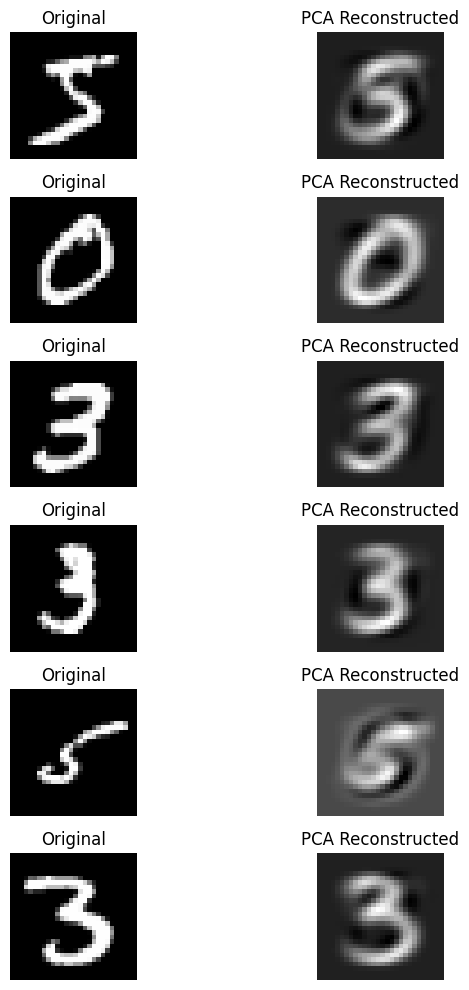

In [ ]:
# Reconstruct images from PCA

'''
Steps:
- Perform the inverse transform in order to get back to original X filtered data.
- Reshape the reconstructed data back to image dimensions for visualization.
- Display the original and reconstructed images.
'''

X_pca_reconstructed = pca.inverse_transform(X_pca)
print("Shape of PCA reconstructed images:", X_pca_reconstructed.shape)

# Reshape reconstructed data back to image dimensions for visualization
X_pca_reconstructed_images = X_pca_reconstructed.reshape(-1, 28, 28)

# Display some original and reconstructed images
import matplotlib.pyplot as plt

n_images_to_display = 6
fig, axes = plt.subplots(n_images_to_display, 2, figsize=(8, 10))

for i in range(n_images_to_display):
    # Original image
    axes[i, 0].imshow(X_filtered[i].reshape(28, 28), cmap='gray')
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')

    # PCA reconstructed image
    axes[i, 1].imshow(X_pca_reconstructed_images[i], cmap='gray')
    axes[i, 1].set_title("PCA Reconstructed")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

### Generate Synthetic Images with K Deep Simplex

In [ ]:
# Github Project: https://github.com/abiy-tasissa/K-Deep-Simplex-KDS-algorithm
'''
Define the model that finds a sparse representation x for the input data y
using an iterative process involving the weight matrix W. The goal is to
the learn the following:

- W: Weight matrix
- X: Sparse matrix that learns the sparse representation of Y

Y = A*X
'''
import torch
import torch.nn as nn
import torch.nn.functional as F

class KDS(nn.Module):
    def __init__(
        self,
        num_layers,
        input_size,
        hidden_size,
        penalty,
        accelerate=True,
        train_step=True,
        W=None,
        step=None,
    ):
        super(KDS, self).__init__()

        # hyperparameters
        self.register_buffer("num_layers", torch.tensor(int(num_layers)))
        self.register_buffer("input_size", torch.tensor(int(input_size)))
        self.register_buffer("hidden_size", torch.tensor(int(hidden_size)))
        self.register_buffer("penalty", torch.tensor(float(penalty)))
        self.register_buffer("accelerate", torch.tensor(bool(accelerate)))

        # parameters
        if W is None:
            W = torch.zeros(self.hidden_size, self.input_size)

        self.register_parameter("W", torch.nn.Parameter(W))
        if step is None:
            step = W.svd().S[0] ** -2
        if train_step:
            self.register_parameter("step", torch.nn.Parameter(step))
        else:
            self.register_buffer("step", step)

    def forward(self, y):
        x = self.encode(y)
        y = self.decode(x)
        return y

    def encode(self, y):
        if self.accelerate:
            return self.encode_accelerated(y)
        else:
            return self.encode_basic(y)

    def encode_basic(self, y):
        x = torch.zeros(y.shape[0], self.hidden_size, device=y.device)
        # weight = (y.unsqueeze(1) - self.W.unsqueeze(0)).pow(2).sum(dim=2)
        weight = (
            y.square().sum(dim=1, keepdims=True)
            + self.W.T.square().sum(dim=0, keepdims=True)
            - 2 * y @ self.W.T
        )
        for layer in range(self.num_layers):
            grad = (x @ self.W - y) @ self.W.T
            grad = grad + weight * self.penalty
            x = self.activate(x - grad * self.step)
        return x

    def encode_accelerated(self, y):
        x_tmp = torch.zeros(y.shape[0], self.hidden_size, device=y.device)
        x_old = torch.zeros(y.shape[0], self.hidden_size, device=y.device)
        # weight = (y.unsqueeze(1) - self.W.unsqueeze(0)).pow(2).sum(dim=2)
        weight = (
            y.square().sum(dim=1, keepdims=True)
            + self.W.T.square().sum(dim=0, keepdims=True)
            - 2 * y @ self.W.T
        )
        for layer in range(self.num_layers):
            grad = (x_tmp @ self.W - y) @ self.W.T
            grad = grad + weight * self.penalty
            x_new = self.activate(x_tmp - grad * self.step)
            x_old, x_tmp = x_new, x_new + layer / (layer + 3) * (x_new - x_old)
        return x_new

    def decode(self, x):
        return x @ self.W

    def activate(self, x):
        m, n = x.shape
        cnt_m = torch.arange(m, device=x.device)
        cnt_n = torch.arange(n, device=x.device)
        u = x.sort(dim=1, descending=True).values
        v = (u.cumsum(dim=1) - 1) / (cnt_n + 1)
        w = v[cnt_m, (u > v).sum(dim=1) - 1]
        return (x - w.view(m, 1)).relu()

In [ ]:
# Loss
class LocalDictionaryLoss(torch.nn.Module):
    def __init__(self, penalty):
        super(LocalDictionaryLoss, self).__init__()
        self.penalty = penalty

    def forward(self, A, y, x):
        return self.forward_detailed(A, y, x)[2]

    def forward_detailed(self, A, y, x):
        weight = (y.unsqueeze(1) - A.unsqueeze(0)).pow(2).sum(dim=2)
        a = 0.5 * (y - x @ A).pow(2).sum(dim=1).mean()
        b = (weight * x).sum(dim=1).mean()
        return a, b, a + b * self.penalty

In [ ]:
def get_mnist_data():
  (x_train, y_train), (x_test, y_test) = mnist.load_data()
  x_all = np.concatenate([x_train, x_test])
  y_all = np.concatenate([y_train, y_test])
  x_all = x_all.reshape(x_all.shape[0], 784).astype(float) / 255.0
  return x_all, y_all

def get_mnist_train_data():
  (x_train, y_train), (x_test, y_test) = mnist.load_data()
  x_train = x_train.reshape(x_train.shape[0], 784).astype(float) / 255.0
  return x_train, y_train

def prune(data, labels, wanted):
    n = len(data)
    idx = [i for i in range(n) if labels[i] in wanted]
    data = data[idx]
    labels = labels[idx]
    lookup = np.arange(int(labels.max() + 1))
    lookup[wanted] = np.arange(len(wanted))
    labels = lookup[labels]
    return data, labels

data, labels = get_mnist_train_data()
data, labels = prune(data, labels, [0, 3, 5])
data /= np.linalg.norm(data, axis=1, keepdims=True)
data = torch.tensor(data).float()
labels = torch.tensor(labels)

print(data.shape)

torch.Size([17475, 784])


In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader
import random
import tensorflow as tf
import numpy as np
from tqdm import tqdm as progress_bar

'''
Steps:
- Convert the filtered data to PyTorch tensors.
- Instantiate the KDS model with the model parameters.
- Define the loss function and optimizer.
- Train the KDS model.
'''

# Instantiate the KDS model
input_size = X_filtered.shape[1]
hidden_size = 100 # This can be tuned, num of columns in dictionary A.
num_layers = 15 # This can be tuned
penalty = 1.0 # Reduced penalty slightly
learning_rate = 0.001 # Further reduced learning rate

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42) # Set torch seed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

net = KDS(
    num_layers=num_layers,
    input_size=input_size,
    hidden_size=hidden_size,
    penalty=penalty,
    accelerate=True,
    train_step=True
)

# Define loss function and optimizer
criterion = LocalDictionaryLoss(penalty=penalty)
optimizer = optim.Adam(net.parameters(), lr=learning_rate) # Adam optimizer
num_epochs = 100 # This can be tuned
clip_value = 0.1  # Adjusted gradient clipping value

with torch.no_grad():
    p = torch.randperm(len(data))[: net.hidden_size]
    net.W.data = data[p]
    net.step.fill_((net.W.data.svd()[1][0] ** -2).item())
net = net.to(device)

for epoch in progress_bar(range(num_epochs)):
    shuffle = torch.randperm(len(data))
    data, labels = data[shuffle], labels[shuffle]
    for i in progress_bar(range(0, len(data), 32), disable=True):
        y = data[i : i + 32].to(device)
        x_hat = net.encode(y)
        loss = criterion(net.W, y, x_hat)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), 1e-4)
        optimizer.step()

    if epoch + 1 % 10 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.4f}")

print("Training finished.")


100%|██████████| 100/100 [48:28<00:00, 29.09s/it]

Training finished.


### Reviewing the KDS Paper for Implementation Details

To help debug the NaN loss issue and ensure the PyTorch implementation aligns with the KDS algorithm, focus on these key areas in the paper (https://arxiv.org/pdf/2012.02134v4):

*   **Section 3: K-Deep Simplex (KDS)**: This section should contain the core algorithm description. Pay close attention to:
    *   The objective function being minimized.
    *   The iterative update rules for both the sparse representation **X** and the dictionary **A** (which corresponds to **W** in the code).
    *   The specific projection step used in the algorithm (the `activate` function in the code). Ensure the implementation accurately reflects this projection.
    *   Any details on the convergence properties or conditions for stability.

*   **Algorithm Box**: If the paper includes a pseudocode or algorithm box, study it carefully. Compare each step in the pseudocode with the corresponding lines of code in the `KDS` class, especially within the `encode_basic` and `encode_accelerated` methods.

*   **Initialization**: Look for details on how the initial weight matrix **W** (or dictionary **A**) and the step size are initialized. Incorrect initialization can sometimes lead to training instability.

*   **Convergence Criteria**: Understand how the algorithm is supposed to converge. While the current training loop uses a fixed number of epochs, the paper might describe convergence criteria based on the change in the objective function or the parameters.

*   **Regularization**: Review the role of the penalty term (`penalty` in the code) and how it affects the optimization. Ensure the penalty term is applied correctly in the gradient calculations.

By carefully examining these sections, you can compare the implementation in the notebook with the algorithm described in the paper and identify any discrepancies that might be causing the instability.

Now that the KDS model is trained, we can use it to generate synthetic images.

Shape of KDS reconstructed images: (17475, 784)


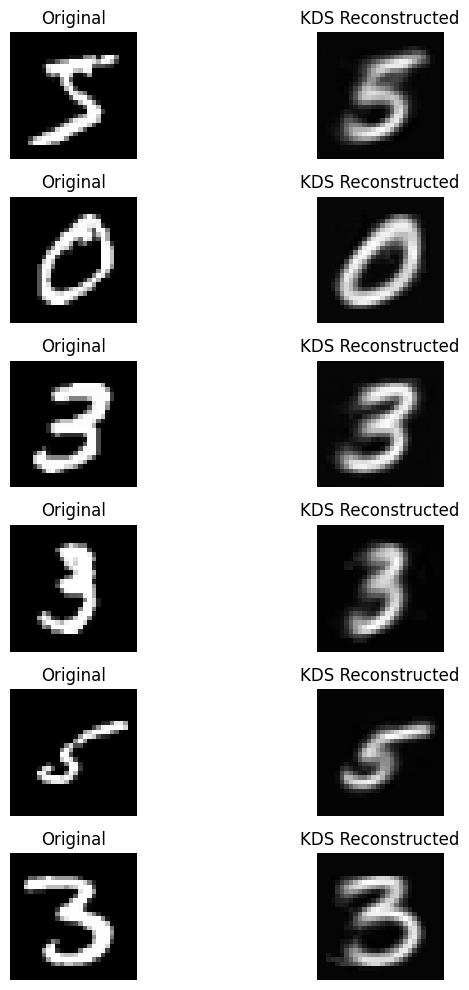

In [ ]:
# Generate synthetic images using the trained KDS model
# We can pass the original filtered data through the trained model
import torch

# Convert X_filtered to a PyTorch tensor before passing it to the model
X_filtered_tensor = torch.from_numpy(X_filtered).float()

X_kds_reconstructed = net(X_filtered_tensor).detach().numpy()

print("Shape of KDS reconstructed images:", X_kds_reconstructed.shape)

# Reshape reconstructed data back to image dimensions for visualization
X_kds_reconstructed_images = X_kds_reconstructed.reshape(-1, 28, 28)

# Display some original and KDS reconstructed images
fig, axes = plt.subplots(n_images_to_display, 2, figsize=(8, 10))

for i in range(n_images_to_display):
    # Original image (need to convert back to numpy for matplotlib if X_filtered was modified)
    # Assuming X_filtered is still the original numpy array from previous cells
    axes[i, 0].imshow(X_filtered[i].reshape(28, 28), cmap='gray')
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')

    # KDS reconstructed image
    axes[i, 1].imshow(X_kds_reconstructed_images[i], cmap='gray')
    axes[i, 1].set_title("KDS Reconstructed")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()